# Figure 1b: HAPS Free-Space Path Loss Comparison

This notebook generates the comparison of free-space path loss at 2 GHz and 38 GHz for HAPS links. It implements Equation (1):

$$L_{FSPL} = 32.44 + 20\log_{10}(f_{MHz}) + 20\log_{10}(d_{km}) \[dB\]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Equation (1): Free-Space Path Loss

The function accepts frequency in MHz and distance in km, matching the original generator script.

In [2]:
def fspl_db(f_mhz, d_km):
    """Calculate free-space path loss in dB."""
    return 32.44 + 20 * np.log10(f_mhz) + 20 * np.log10(d_km)

## Parameters and calculations

In [3]:
d_km = np.linspace(1, 100, 500)
f_2ghz = 2000
f_38ghz = 38000

fspl_2ghz = fspl_db(f_2ghz, d_km)
fspl_38ghz = fspl_db(f_38ghz, d_km)

fspl_diff = fspl_38ghz - fspl_2ghz
fspl_diff_at_100km = fspl_diff[0]

print(f"FSPL difference (38 GHz - 2 GHz): {fspl_diff_at_100km:.2f} dB (constant offset)")
print(f"Theoretical: 20*log10(38/2) = {20 * np.log10(38 / 2):.2f} dB")

FSPL difference (38 GHz - 2 GHz): 25.58 dB (constant offset)
Theoretical: 20*log10(38/2) = 25.58 dB


## Generate Figure 1b


[OK] Figure saved: ../output/1b_haps_fspl_2ghz_vs_38ghz.png


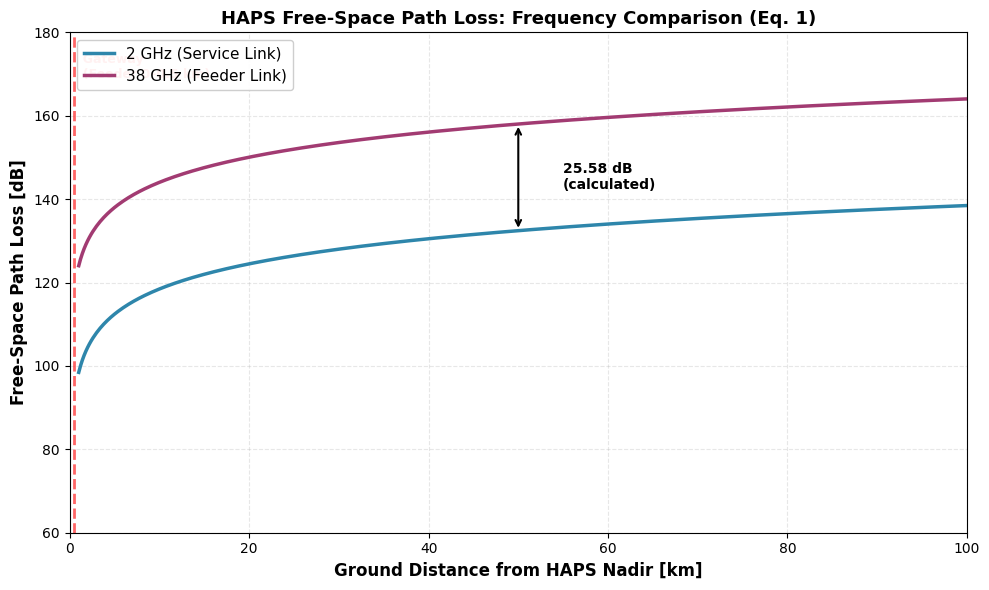

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(d_km, fspl_2ghz, linewidth=2.5, label='2 GHz (Service Link)', color='#2E86AB', linestyle='-')
ax.plot(d_km, fspl_38ghz, linewidth=2.5, label='38 GHz (Feeder Link)', color='#A23B72', linestyle='-')

ax.set_xlabel('Ground Distance from HAPS Nadir [km]', fontsize=12, fontweight='bold')
ax.set_ylabel('Free-Space Path Loss [dB]', fontsize=12, fontweight='bold')
ax.set_title('HAPS Free-Space Path Loss: Frequency Comparison (Eq. 1)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

mid_point = 50
offset_y_2 = fspl_db(f_2ghz, mid_point)
offset_y_38 = fspl_db(f_38ghz, mid_point)
ax.annotate('', xy=(mid_point, offset_y_38), xytext=(mid_point, offset_y_2),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
freq_offset_db = 20 * np.log10(38 / 2)
ax.text(mid_point + 5, (offset_y_2 + offset_y_38) / 2,
        f'{freq_offset_db:.2f} dB\n(calculated)', fontsize=10, fontweight='bold', va='center')

gateway_distance_km = 0.5
ax.axvline(x=gateway_distance_km, color='red', linestyle='--', linewidth=2, alpha=0.6,
           label=f'Gateway (feeder link: 0–{gateway_distance_km} km)')
ax.text(gateway_distance_km, 175, f'  Gateway\n  (Feeder 0–{gateway_distance_km} km)',
        fontsize=9, color='red', weight='bold', va='top')

ax.set_ylim([60, 180])
ax.set_xlim([0, 100])
plt.tight_layout()
plt.savefig('../output/1b_haps_fspl_2ghz_vs_38ghz.png', dpi=300, bbox_inches='tight')
print('\n[OK] Figure saved: ../output/1b_haps_fspl_2ghz_vs_38ghz.png')
plt.show()
plt.close(fig)

## Summary

In [5]:
print('\n' + '=' * 70)
print('Figure 1b Summary')
print('=' * 70)
print('HAPS Altitude: 20 km')
print('Ground Distance Range: 1–100 km')
print('Frequency 1 (Service Link): 2 GHz')
print('Frequency 2 (Feeder Link): 38 GHz')
print(f'Path Loss Difference: {fspl_diff_at_100km:.2f} dB (constant, frequency-dependent only)')
print(f'FSPL at 100 km, 2 GHz: {fspl_db(f_2ghz, 100):.2f} dB')
print(f'FSPL at 100 km, 38 GHz: {fspl_db(f_38ghz, 100):.2f} dB')
print('=' * 70)


Figure 1b Summary
HAPS Altitude: 20 km
Ground Distance Range: 1–100 km
Frequency 1 (Service Link): 2 GHz
Frequency 2 (Feeder Link): 38 GHz
Path Loss Difference: 25.58 dB (constant, frequency-dependent only)
FSPL at 100 km, 2 GHz: 138.46 dB
FSPL at 100 km, 38 GHz: 164.04 dB
